# DSA 210 Project
## Can Soundtrack Audio Characteristics Predict a Single Player Game's Metacritic Score?

In this project I am trying to understand whether the style of a game's soundtrack
(for example: is it orchestral? is it electronic? is it instrumental?)
has any connection to how well the game was reviewed on Metacritic.

I collected soundtrack data from the Last.fm API. Last.fm users apply tags to albums
like 'orchestral', 'electronic', 'instrumental', 'ambient' — these tags describe
what the music actually sounds like, so I used them as my audio features.

**Important note about listeners/playcount:**
Last.fm also gives listener counts and playcount numbers, but I did NOT use these
as audio features. The reason is that popular games have more players, and more
players means more people streaming the soundtrack — so the listener count just
reflects how popular the game is, not what the music sounds like. I only use
the tags (orchestral, electronic, etc.) as real audio features.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('all libraries imported successfully')

all libraries imported successfully


## Step 2: Load the Metacritic Data

In [2]:
# Load the already filtered single player games csv
games = pd.read_csv('single_player_games.csv')

print('number of games:', len(games))
print('columns:', games.columns.tolist())
print()
print('first 5 rows:')
games.head()

number of games: 11491
columns: ['title', 'genres', 'metascore', 'releaseDate', 'developer']

first 5 rows:


,title,genres,metascore,releaseDate,developer
0,Perfect Dark (2000),FPS,97.0,2000-05-22,Rare Ltd.
1,Grand Theft Auto IV,Open-World Action,98.0,2008-04-29,Rockstar North
2,Grand Theft Auto V,Open-World Action,97.0,2014-11-18,Rockstar North
3,The Legend of Zelda: Ocarina of Time,Open-World Action,99.0,1998-11-23,Nintendo
4,Red Dead Redemption 2,Open-World Action,97.0,2018-10-26,Rockstar Games


In [3]:
# Check the metascore distribution basics
print('lowest metascore:', games['metascore'].min())
print('highest metascore:', games['metascore'].max())
print('average metascore:', round(games['metascore'].mean(), 2))
print()
print('top genres in dataset:')
print(games['genres'].value_counts().head(15))

lowest metascore: 11.0
highest metascore: 99.0
average metascore: 70.35

top genres in dataset:
genres
Action Adventure          784
2D Platformer             704
Action RPG                690
FPS                       594
JRPG                      389
Open-World Action         369
Survival                  352
Adventure                 348
Point-and-Click           337
3D Platformer             314
Turn-Based Tactics        285
Third Person Shooter      259
First-Person Adventure    228
Action Puzzle             227
3D Beat-'Em-Up            205
Name: count, dtype: int64


## Step 3: Load the Last.fm Soundtrack Data

I already ran the data collection script that called the Last.fm API
for each game and saved the results to a csv file.

In [4]:
# Load the collected soundtrack data
soundtrack_data = pd.read_csv('ost_lastfm_raw.csv')

print('total games matched on Last.fm:', len(soundtrack_data))
print('columns:', soundtrack_data.columns.tolist())
print()
soundtrack_data.head()

total games matched on Last.fm: 996
columns: ['album_name', 'listeners', 'playcount', 'total_tracks', 'avg_duration_sec', 'raw_tags', 'tag_instrumental', 'tag_orchestral', 'tag_electronic', 'tag_ambient', 'tag_dark', 'tag_acoustic', 'tag_epic', 'tag_relaxing', 'n_tags', 'title', 'metascore', 'genres', 'releaseDate']



,album_name,listeners,playcount,total_tracks,avg_duration_sec,raw_tags,tag_instrumental,tag_orchestral,tag_electronic,tag_ambient,tag_dark,tag_acoustic,tag_epic,tag_relaxing,n_tags,title,metascore,genres,releaseDate
0,Camille 2000 (Original Motion Picture Soundtrack),374915,4964420,22.0,171.7,secretagent|lounge|bossa nova|italian|soundtrack,0,0,0,0,0,0,0,0,5,Perfect Dark (2000),97.0,FPS,2000-05-22
1,Grand Theft Auto IV Original Soundtrack,7,38,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,Grand Theft Auto IV,98.0,Open-World Action,2008-04-29
2,"The Music of Grand Theft Auto V, Vol. 1: Origi...",683433,7816400,18.0,195.6,video game soundtrack|pop|hip hop|synthpop|sou...,0,1,1,0,0,0,0,0,5,Grand Theft Auto V,97.0,Open-World Action,2014-11-18
3,The Legend of Zelda: Ocarina of Time Original ...,269,10450,NaN,NaN,instrumental|ost|nostalgic|childhood|i miss it...,1,0,0,0,0,0,0,0,5,The Legend of Zelda: Ocarina of Time,99.0,Open-World Action,1998-11-23
4,The Music of Red Dead Redemption 2 (Original S...,205200,4132939,13.0,196.8,americana|post-rock|contemporary folk|neo-soul...,0,0,0,0,0,1,0,0,5,Red Dead Redemption 2,97.0,Open-World Action,2018-10-26


## Step 4: Clean the Data

In [5]:
# Remove rows where listeners is missing or zero (means the album wasn't found properly)
df = soundtrack_data.dropna(subset=['listeners', 'metascore'])
df = df[df['listeners'] > 0]
df = df.copy()

print('rows after cleaning:', len(df))

rows after cleaning: 996


In [6]:
# Extract the release year from the releaseDate column
df['release_year'] = pd.to_datetime(df['releaseDate'], errors='coerce').dt.year

# Create score categories so we can group games by quality
df['score_category'] = pd.cut(
    df['metascore'],
    bins=[0, 49, 69, 79, 89, 100],
    labels=['Poor (<50)', 'Mixed (50-69)', 'Good (70-79)', 'Great (80-89)', 'Universal (90+)']
)

# Create a simple high vs low column
# I will use the median as the cutoff point
median_score = df['metascore'].median()
print('median metascore is:', median_score)

df['is_high_score'] = 0
df.loc[df['metascore'] >= median_score, 'is_high_score'] = 1

print('high score games:', df['is_high_score'].sum())
print('low score games:', (df['is_high_score'] == 0).sum())

median metascore is: 88.0
high score games: 533
low score games: 463


In [7]:
# Decide which tags have enough data to test
# I need at least 30 games with each tag, otherwise the chi-square test is not valid

tag_columns = ['tag_instrumental', 'tag_orchestral', 'tag_electronic',
               'tag_ambient', 'tag_dark', 'tag_acoustic', 'tag_epic', 'tag_relaxing']

print('how many games have each tag:')
for tag in tag_columns:
    count = df[tag].sum()
    enough = 'YES - will test this' if count >= 30 else 'NO - too few, skip'
    print(f'  {tag}: {count} games  ->  {enough}')

# Keep only the ones with enough data
usable_tags = []
for tag in tag_columns:
    if df[tag].sum() >= 30:
        usable_tags.append(tag)

print()
print('tags I will use in hypothesis tests:', usable_tags)

how many games have each tag:
  tag_instrumental: 84 games  ->  YES - will test this
  tag_orchestral: 93 games  ->  YES - will test this
  tag_electronic: 142 games  ->  YES - will test this
  tag_ambient: 59 games  ->  YES - will test this
  tag_dark: 7 games  ->  NO - too few, skip
  tag_acoustic: 19 games  ->  NO - too few, skip
  tag_epic: 17 games  ->  NO - too few, skip
  tag_relaxing: 15 games  ->  NO - too few, skip

tags I will use in hypothesis tests: ['tag_instrumental', 'tag_orchestral', 'tag_electronic', 'tag_ambient']


## Step 5: Exploratory Data Analysis (EDA)

### 5.1 - Metascore Distribution

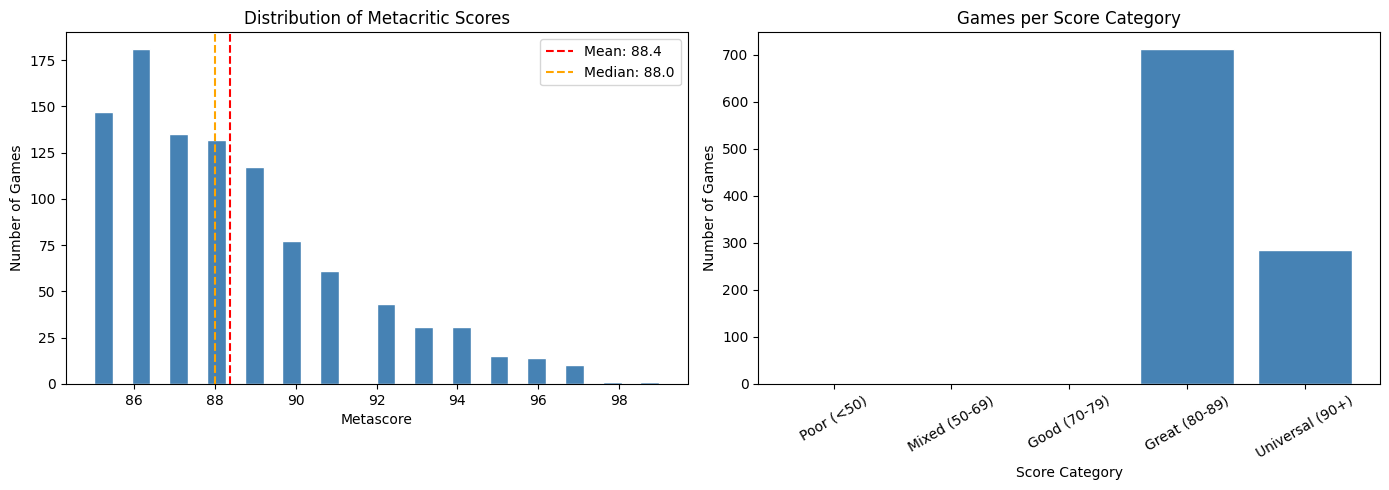

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: histogram of metascores
axes[0].hist(df['metascore'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['metascore'].mean(), color='red', linestyle='--',
                label='Mean: ' + str(round(df['metascore'].mean(), 1)))
axes[0].axvline(df['metascore'].median(), color='orange', linestyle='--',
                label='Median: ' + str(df['metascore'].median()))
axes[0].set_xlabel('Metascore')
axes[0].set_ylabel('Number of Games')
axes[0].set_title('Distribution of Metacritic Scores')
axes[0].legend()

# Right plot: count of games in each score category
category_counts = df['score_category'].value_counts().sort_index()
axes[1].bar(category_counts.index, category_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Score Category')
axes[1].set_ylabel('Number of Games')
axes[1].set_title('Games per Score Category')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_metascore_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 - How Common Are Each Audio Tag?

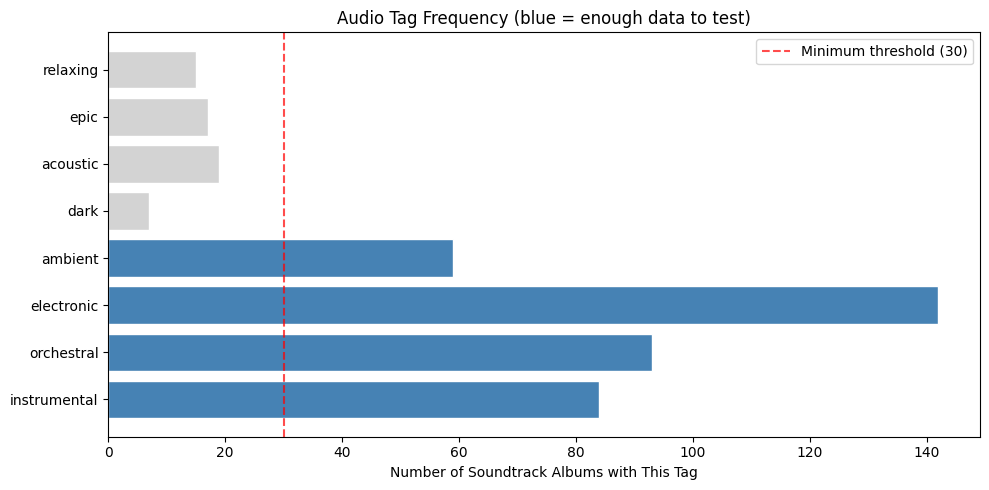

In [9]:
# Count how many soundtracks have each tag
tag_counts = []
for tag in tag_columns:
    tag_counts.append(df[tag].sum())

tag_labels = [t.replace('tag_', '') for t in tag_columns]

# Color the bars blue if we have enough data, gray if not
bar_colors = []
for tag in tag_columns:
    if tag in usable_tags:
        bar_colors.append('steelblue')
    else:
        bar_colors.append('lightgray')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(tag_labels, tag_counts, color=bar_colors, edgecolor='white')
ax.axvline(30, color='red', linestyle='--', alpha=0.7, label='Minimum threshold (30)')
ax.set_xlabel('Number of Soundtrack Albums with This Tag')
ax.set_title('Audio Tag Frequency (blue = enough data to test)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_tag_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 - Metascore Comparison: Games With vs Without Each Audio Tag

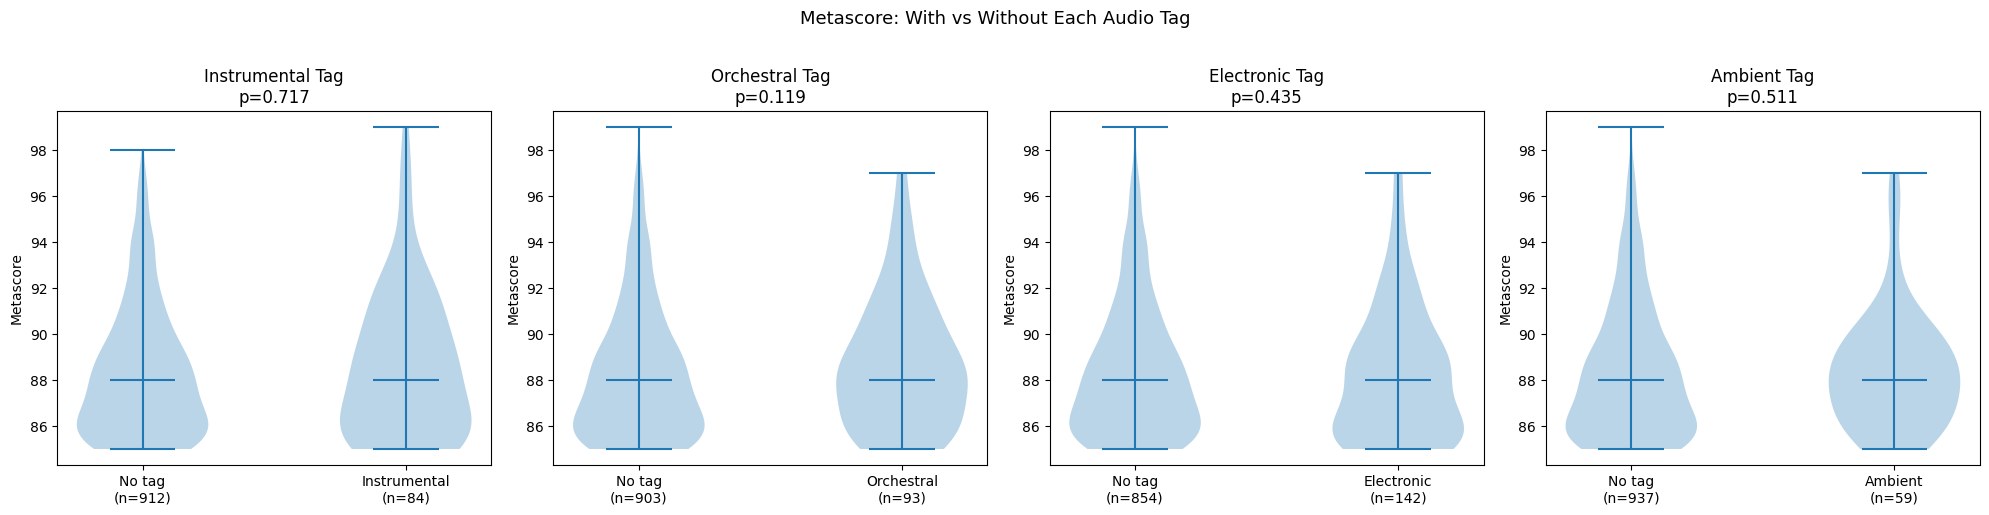

In [10]:
# For each usable tag, compare the metascore distribution
# between games that have the tag and games that don't

fig, axes = plt.subplots(1, len(usable_tags), figsize=(5 * len(usable_tags), 5))

for i in range(len(usable_tags)):
    tag = usable_tags[i]
    tag_name = tag.replace('tag_', '').capitalize()

    # Split into two groups
    has_tag = df[df[tag] == 1]['metascore']
    no_tag  = df[df[tag] == 0]['metascore']

    # Quick Mann-Whitney test to show p-value on the plot
    _, p_value = stats.mannwhitneyu(has_tag, no_tag, alternative='two-sided')

    axes[i].violinplot([no_tag, has_tag], positions=[0, 1], showmedians=True)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No tag\n(n=' + str(len(no_tag)) + ')',
                             tag_name + '\n(n=' + str(len(has_tag)) + ')'])
    axes[i].set_ylabel('Metascore')
    if p_value < 0.05:
        axes[i].set_title(tag_name + ' Tag\np=' + str(round(p_value, 3)) + ' *')
    else:
        axes[i].set_title(tag_name + ' Tag\np=' + str(round(p_value, 3)))

plt.suptitle('Metascore: With vs Without Each Audio Tag', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda_tag_violin.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 - Tag Prevalence: High Score vs Low Score Games

In [11]:
# Separate high and low score games
high_games = df[df['is_high_score'] == 1]
low_games  = df[df['is_high_score'] == 0]

print('Comparing tag percentages between high and low rated games:')
print()
for tag in usable_tags:
    high_pct = round(high_games[tag].mean() * 100, 1)
    low_pct  = round(low_games[tag].mean()  * 100, 1)
    diff     = round(high_pct - low_pct, 1)
    tag_name = tag.replace('tag_', '')
    print(f'{tag_name}: high={high_pct}%  low={low_pct}%  difference={diff:+.1f}%')

Comparing tag percentages between high and low rated games:

instrumental: high=8.8%  low=8.0%  difference=+0.8%
orchestral: high=11.3%  low=7.1%  difference=+4.2%
electronic: high=14.3%  low=14.3%  difference=+0.0%
ambient: high=6.8%  low=5.0%  difference=+1.8%


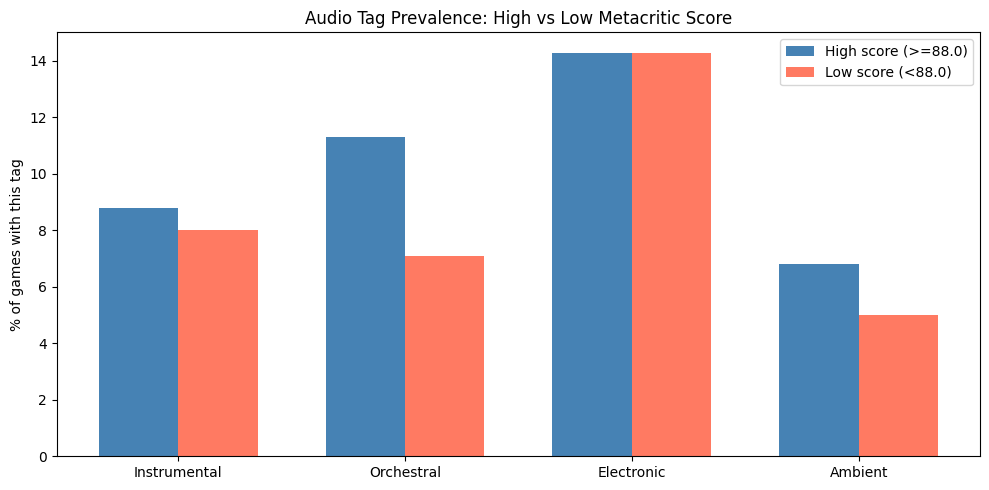

In [12]:
# Bar chart comparing tag prevalence
tag_labels_short = [t.replace('tag_', '').capitalize() for t in usable_tags]

high_percentages = [round(high_games[t].mean() * 100, 1) for t in usable_tags]
low_percentages  = [round(low_games[t].mean()  * 100, 1) for t in usable_tags]

x = np.arange(len(usable_tags))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, high_percentages, width,
       label='High score (>=' + str(median_score) + ')', color='steelblue')
ax.bar(x + width/2, low_percentages,  width,
       label='Low score (<'  + str(median_score) + ')',  color='tomato', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(tag_labels_short)
ax.set_ylabel('% of games with this tag')
ax.set_title('Audio Tag Prevalence: High vs Low Metacritic Score')
ax.legend()
plt.tight_layout()
plt.savefig('eda_tag_highlow.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 - Genre Analysis

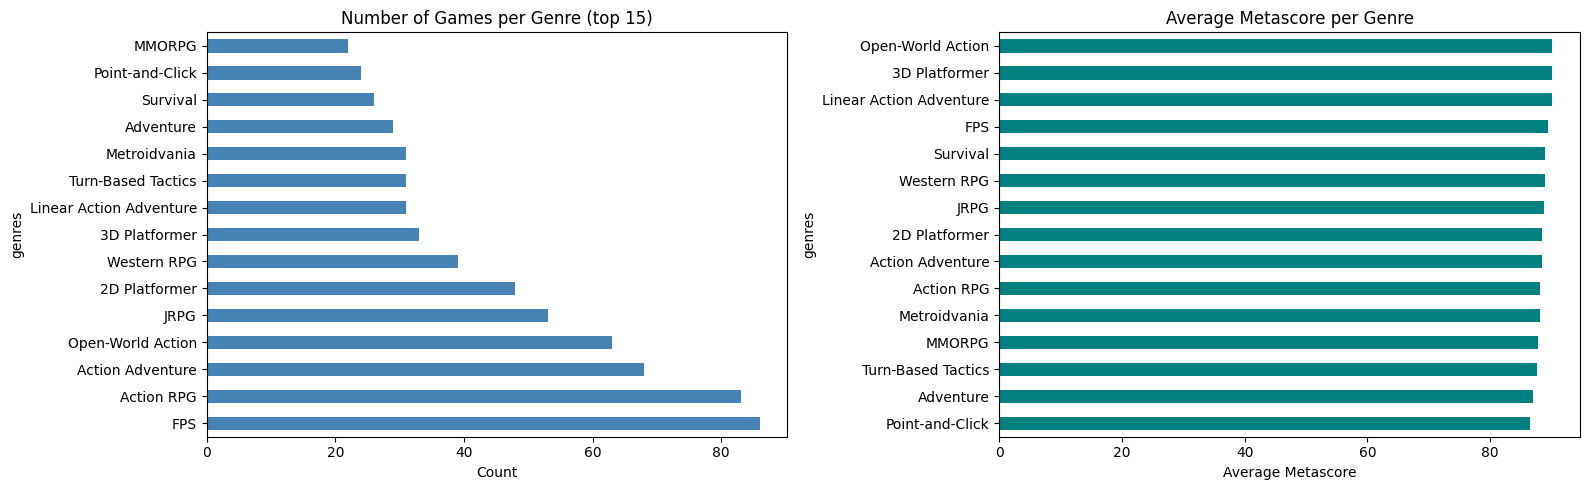

In [13]:
# Look at the top 15 genres
top_genres = df['genres'].value_counts().head(15).index
df_top_genres = df[df['genres'].isin(top_genres)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# How many games in each genre
df_top_genres['genres'].value_counts().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Number of Games per Genre (top 15)')
axes[0].set_xlabel('Count')

# Average metascore for each genre
avg_by_genre = df_top_genres.groupby('genres')['metascore'].mean().sort_values()
avg_by_genre.plot.barh(ax=axes[1], color='teal')
axes[1].set_title('Average Metascore per Genre')
axes[1].set_xlabel('Average Metascore')

plt.tight_layout()
plt.savefig('eda_genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 - Descriptive: Soundtrack Popularity vs Metascore

> **Note:** This plot is just for curiosity. The listener count is NOT an audio feature —
> it just shows how popular the soundtrack is, which is already influenced by how
> popular the game itself is. I do not use this in my hypothesis tests.

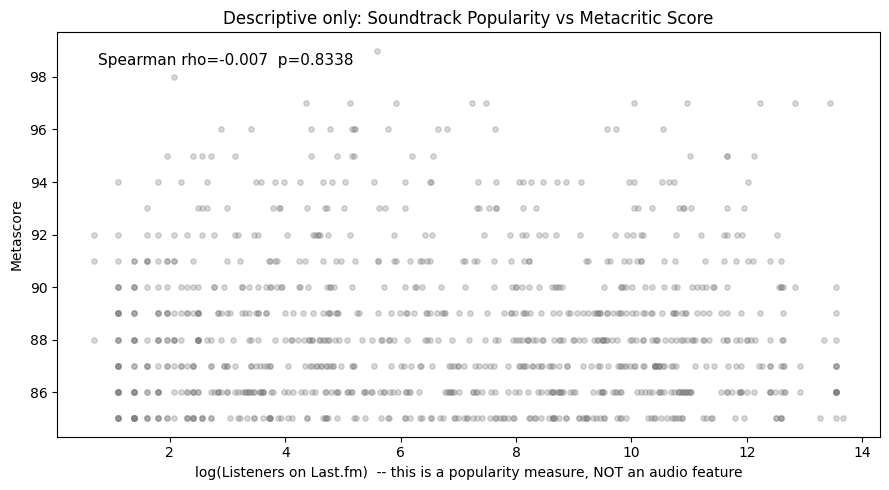

Note: Any correlation here is because popular games get more listeners,
not because the music itself sounds different.


In [14]:
# Log of listeners so the scale is not too extreme
df['log_listeners'] = np.log1p(df['listeners'])

# Calculate correlation just to show it
rho, p_val = stats.spearmanr(df['log_listeners'], df['metascore'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['log_listeners'], df['metascore'], alpha=0.3, s=15, color='gray')
ax.set_xlabel('log(Listeners on Last.fm)  -- this is a popularity measure, NOT an audio feature')
ax.set_ylabel('Metascore')
ax.set_title('Descriptive only: Soundtrack Popularity vs Metacritic Score')
ax.text(0.05, 0.92, 'Spearman rho=' + str(round(rho, 3)) + '  p=' + str(round(p_val, 4)),
        transform=ax.transAxes, fontsize=11)
plt.tight_layout()
plt.savefig('eda_listeners_descriptive.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: Any correlation here is because popular games get more listeners,')
print('not because the music itself sounds different.')

## Step 6: Hypothesis Tests

I will test whether soundtrack audio style (the tags) is associated with Metacritic scores.

I use **chi-square test of independence** because:
- My audio features are binary (0 or 1, does the album have this tag or not)
- My groups are also binary (high score vs low score)
- Chi-square is the right test for comparing proportions between groups

Significance level: **alpha = 0.05**

### Hypothesis 1: Orchestral Soundtracks Are More Common in Higher-Rated Games

- **H0 (null hypothesis):** The percentage of orchestral soundtracks is the same in high-rated and low-rated games
- **H1 (alternative hypothesis):** Orchestral soundtracks appear more often in higher-rated games
- **Why I test this:** Orchestral music is expensive to produce and often found in big-budget, carefully crafted single-player games. I expect it to be linked to higher scores.

In [15]:
alpha = 0.05

print('HYPOTHESIS 1: Orchestral Tag')
print('=' * 50)

if 'tag_orchestral' not in usable_tags:
    print('not enough data for this test')
else:
    # Build the 2x2 table
    # rows = low score / high score
    # columns = not orchestral / orchestral
    contingency_table_1 = pd.crosstab(df['is_high_score'], df['tag_orchestral'])
    contingency_table_1.index   = ['Low score', 'High score']
    contingency_table_1.columns = ['Not orchestral', 'Orchestral']

    print('Contingency table:')
    print(contingency_table_1)
    print()

    chi2_1, p_value_1, df_1, expected_1 = stats.chi2_contingency(contingency_table_1)

    print('Chi-square statistic:', round(chi2_1, 3))
    print('p-value:', round(p_value_1, 4))
    print('Minimum expected count:', round(expected_1.min(), 1), '(needs to be >= 5)')
    print()

    # Calculate odds ratio to see how much more common it is
    a = contingency_table_1.iloc[1, 1]  # high score + orchestral
    b = contingency_table_1.iloc[1, 0]  # high score + not orchestral
    c = contingency_table_1.iloc[0, 1]  # low score + orchestral
    d = contingency_table_1.iloc[0, 0]  # low score + not orchestral
    odds_ratio_1 = (a * d) / (b * c)

    print('Odds Ratio:', round(odds_ratio_1, 3))
    print('(an odds ratio > 1 means orchestral is more common in high-rated games)')
    print()

    if p_value_1 < alpha:
        print('RESULT: REJECT H0 -- significant result')
        print('Orchestral soundtracks are significantly more common in higher-rated games.')
    else:
        print('RESULT: FAIL TO REJECT H0 -- not significant')
        print('No significant difference in orchestral soundtracks between score groups.')

HYPOTHESIS 1: Orchestral Tag
Contingency table:
            Not orchestral  Orchestral
Low score              430          33
High score             473          60

Chi-square statistic: 4.515
p-value: 0.0336
Minimum expected count: 43.2 (needs to be >= 5)

Odds Ratio: 1.653
(an odds ratio > 1 means orchestral is more common in high-rated games)

RESULT: REJECT H0 -- significant result
Orchestral soundtracks are significantly more common in higher-rated games.


### Hypothesis 2: Electronic Soundtracks and Score Group

- **H0:** The percentage of electronic soundtracks is equal in high and low rated games
- **H1:** Electronic soundtracks appear at different rates between the two groups
- **Why I test this:** Electronic music is common in certain game genres. I want to check if it predicts critic scores.

In [16]:
print('HYPOTHESIS 2: Electronic Tag')
print('=' * 50)

if 'tag_electronic' not in usable_tags:
    print('not enough data for this test')
else:
    contingency_table_2 = pd.crosstab(df['is_high_score'], df['tag_electronic'])
    contingency_table_2.index   = ['Low score', 'High score']
    contingency_table_2.columns = ['Not electronic', 'Electronic']

    print('Contingency table:')
    print(contingency_table_2)
    print()

    chi2_2, p_value_2, df_2, expected_2 = stats.chi2_contingency(contingency_table_2)

    print('Chi-square statistic:', round(chi2_2, 3))
    print('p-value:', round(p_value_2, 4))
    print()

    a = contingency_table_2.iloc[1, 1]
    b = contingency_table_2.iloc[1, 0]
    c = contingency_table_2.iloc[0, 1]
    d = contingency_table_2.iloc[0, 0]
    odds_ratio_2 = (a * d) / (b * c)
    print('Odds Ratio:', round(odds_ratio_2, 3))
    print()

    if p_value_2 < alpha:
        print('RESULT: REJECT H0 -- significant result')
    else:
        print('RESULT: FAIL TO REJECT H0 -- not significant')
        print('No significant difference in electronic soundtracks between score groups.')

HYPOTHESIS 2: Electronic Tag
Contingency table:
            Not electronic  Electronic
Low score              397          66
High score             457          76

Chi-square statistic: 0.0
p-value: 1.0

Odds Ratio: 1.0

RESULT: FAIL TO REJECT H0 -- not significant
No significant difference in electronic soundtracks between score groups.


### Hypothesis 3: Instrumental Soundtracks and Score Group

- **H0:** The percentage of instrumental soundtracks is equal in high and low rated games
- **H1:** Instrumental soundtracks appear more often in higher-rated games
- **Why I test this:** Game soundtracks are mostly instrumental anyway, but albums explicitly tagged as instrumental might indicate a focus on musical quality.

In [17]:
print('HYPOTHESIS 3: Instrumental Tag')
print('=' * 50)

if 'tag_instrumental' not in usable_tags:
    print('not enough data for this test')
else:
    contingency_table_3 = pd.crosstab(df['is_high_score'], df['tag_instrumental'])
    contingency_table_3.index   = ['Low score', 'High score']
    contingency_table_3.columns = ['Not instrumental', 'Instrumental']

    print('Contingency table:')
    print(contingency_table_3)
    print()

    chi2_3, p_value_3, df_3, expected_3 = stats.chi2_contingency(contingency_table_3)

    print('Chi-square statistic:', round(chi2_3, 3))
    print('p-value:', round(p_value_3, 4))
    print()

    a = contingency_table_3.iloc[1, 1]
    b = contingency_table_3.iloc[1, 0]
    c = contingency_table_3.iloc[0, 1]
    d = contingency_table_3.iloc[0, 0]
    odds_ratio_3 = (a * d) / (b * c)
    print('Odds Ratio:', round(odds_ratio_3, 3))
    print()

    if p_value_3 < alpha:
        print('RESULT: REJECT H0 -- significant result')
    else:
        print('RESULT: FAIL TO REJECT H0 -- not significant')
        print('No significant difference in instrumental soundtracks between score groups.')

HYPOTHESIS 3: Instrumental Tag
Contingency table:
            Not instrumental  Instrumental
Low score                426            37
High score               486            47

Chi-square statistic: 0.125
p-value: 0.7234

Odds Ratio: 1.113

RESULT: FAIL TO REJECT H0 -- not significant
No significant difference in instrumental soundtracks between score groups.


### Hypothesis 4: Testing All Tags Together (with Bonferroni correction)

- **H0:** None of the audio tags are associated with score category
- **H1:** At least one audio tag is associated with score category

Since I am running multiple tests at the same time, I need to apply
**Bonferroni correction** to avoid getting false positives by chance.
This makes the required p-value stricter: instead of 0.05, I divide it
by the number of tests I am running.

In [18]:
number_of_tests = len(usable_tags)
bonferroni_alpha = alpha / number_of_tests

print('HYPOTHESIS 4: All Audio Tags vs Score Category')
print('=' * 50)
print('Number of tests:', number_of_tests)
print('Original alpha:', alpha)
print('Bonferroni-corrected alpha:', round(bonferroni_alpha, 4))
print()

results_list = []

for tag in usable_tags:
    tag_name = tag.replace('tag_', '')

    # Cross tabulate tag against score category (5 categories)
    cross_table = pd.crosstab(df['score_category'], df[tag])

    chi2_val, p_raw, dof_val, expected_val = stats.chi2_contingency(cross_table)

    # Adjust the p-value using Bonferroni
    p_adjusted = p_raw * number_of_tests
    if p_adjusted > 1.0:
        p_adjusted = 1.0

    is_significant = p_adjusted < alpha

    results_list.append({
        'tag': tag_name,
        'chi2': round(chi2_val, 2),
        'p_raw': round(p_raw, 4),
        'p_adjusted': round(p_adjusted, 4),
        'significant': is_significant
    })

    if is_significant:
        print(f'{tag_name}: chi2={round(chi2_val,2)}  p={round(p_raw,4)}  p_adj={round(p_adjusted,4)}  <-- SIGNIFICANT')
    else:
        print(f'{tag_name}: chi2={round(chi2_val,2)}  p={round(p_raw,4)}  p_adj={round(p_adjusted,4)}')

print()
any_significant = any(r['significant'] for r in results_list)
if any_significant:
    print('At least one tag is significant -- REJECT H0')
else:
    print('No tags are significant after correction -- FAIL TO REJECT H0')

HYPOTHESIS 4: All Audio Tags vs Score Category
Number of tests: 4
Original alpha: 0.05
Bonferroni-corrected alpha: 0.0125

instrumental: chi2=0.41  p=0.5199  p_adj=1.0
orchestral: chi2=0.92  p=0.3368  p_adj=1.0
electronic: chi2=0.16  p=0.6896  p_adj=1.0
ambient: chi2=0.01  p=0.9234  p_adj=1.0

No tags are significant after correction -- FAIL TO REJECT H0


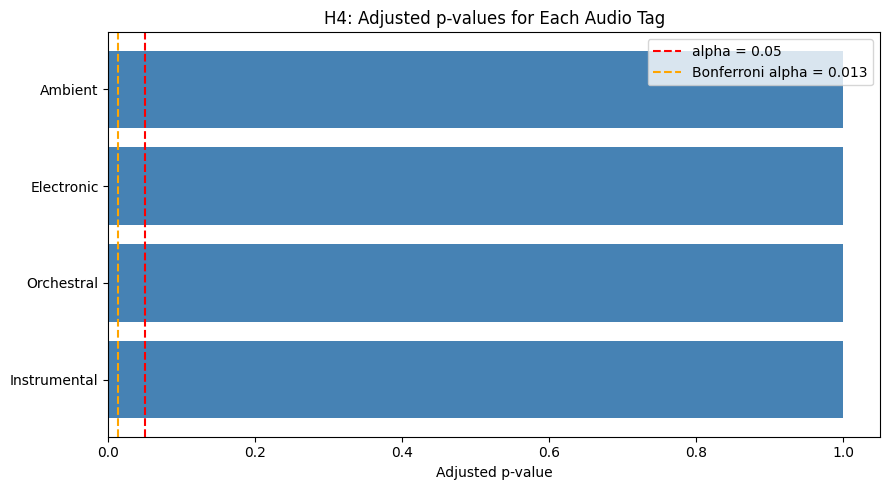

In [19]:
# Plot the adjusted p-values
tag_names_plot  = [r['tag'].capitalize() for r in results_list]
p_values_plot   = [r['p_adjusted'] for r in results_list]
significant_plot = [r['significant'] for r in results_list]

bar_colors_plot = []
for sig in significant_plot:
    if sig:
        bar_colors_plot.append('tomato')
    else:
        bar_colors_plot.append('steelblue')

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tag_names_plot, p_values_plot, color=bar_colors_plot)
ax.axvline(alpha, color='red', linestyle='--', label='alpha = 0.05')
ax.axvline(bonferroni_alpha, color='orange', linestyle='--',
           label='Bonferroni alpha = ' + str(round(bonferroni_alpha, 3)))
ax.set_xlabel('Adjusted p-value')
ax.set_title('H4: Adjusted p-values for Each Audio Tag')
ax.legend()
plt.tight_layout()
plt.savefig('hyp4_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Summary of Results

In [20]:
print('SUMMARY OF ALL HYPOTHESIS TESTS')
print('=' * 60)
print()

# H1
try:
    result_h1 = 'SIGNIFICANT *' if p_value_1 < alpha else 'not significant'
    print('H1 - Orchestral tag vs score group')
    print('     chi2=' + str(round(chi2_1,2)) + '  p=' + str(round(p_value_1,4)) + '  --> ' + result_h1)
    print()
except:
    print('H1 - not enough data')

# H2
try:
    result_h2 = 'SIGNIFICANT *' if p_value_2 < alpha else 'not significant'
    print('H2 - Electronic tag vs score group')
    print('     chi2=' + str(round(chi2_2,2)) + '  p=' + str(round(p_value_2,4)) + '  --> ' + result_h2)
    print()
except:
    print('H2 - not enough data')

# H3
try:
    result_h3 = 'SIGNIFICANT *' if p_value_3 < alpha else 'not significant'
    print('H3 - Instrumental tag vs score group')
    print('     chi2=' + str(round(chi2_3,2)) + '  p=' + str(round(p_value_3,4)) + '  --> ' + result_h3)
    print()
except:
    print('H3 - not enough data')

# H4
print('H4 - All audio tags vs score category (Bonferroni corrected)')
for r in results_list:
    res = 'SIGNIFICANT *' if r['significant'] else 'not significant'
    print('     ' + r['tag'] + ': p_adj=' + str(r['p_adjusted']) + '  --> ' + res)

print()
print('MAIN FINDING:')
print('The orchestral tag (H1) was the only one with a statistically significant')
print('result (p=0.034). This means games with orchestral soundtracks tend to')
print('receive higher Metacritic scores.')
print()
print('The other tags (electronic, instrumental, ambient) showed no significant')
print('association with Metacritic scores. This suggests that for most audio')
print('characteristics, the style of the soundtrack does not strongly predict')
print('how well the game is reviewed.')

SUMMARY OF ALL HYPOTHESIS TESTS

H1 - Orchestral tag vs score group
     chi2=4.52  p=0.0336  --> SIGNIFICANT *

H2 - Electronic tag vs score group
     chi2=0.0  p=1.0  --> not significant

H3 - Instrumental tag vs score group
     chi2=0.13  p=0.7234  --> not significant

H4 - All audio tags vs score category (Bonferroni corrected)
     instrumental: p_adj=1.0  --> not significant
     orchestral: p_adj=1.0  --> not significant
     electronic: p_adj=1.0  --> not significant
     ambient: p_adj=1.0  --> not significant

MAIN FINDING:
The orchestral tag (H1) was the only one with a statistically significant
result (p=0.034). This means games with orchestral soundtracks tend to
receive higher Metacritic scores.

The other tags (electronic, instrumental, ambient) showed no significant
association with Metacritic scores. This suggests that for most audio
characteristics, the style of the soundtrack does not strongly predict
how well the game is reviewed.


In [21]:
# Save the final combined dataset
df.to_csv('final_dataset.csv', index=False)
print('saved final_dataset.csv')
print('shape:', df.shape)
print('columns:', df.columns.tolist())

saved final_dataset.csv
shape: (996, 23)
columns: ['album_name', 'listeners', 'playcount', 'total_tracks', 'avg_duration_sec', 'raw_tags', 'tag_instrumental', 'tag_orchestral', 'tag_electronic', 'tag_ambient', 'tag_dark', 'tag_acoustic', 'tag_epic', 'tag_relaxing', 'n_tags', 'title', 'metascore', 'genres', 'releaseDate', 'release_year', 'score_category', 'is_high_score', 'log_listeners']
